In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("battery_training_data.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1500, 6)
   cycle_count  temperature_c  daily_usage_hours  charging_frequency_per_day  \
0          125          37.47               6.19                        1.84   
1          934          44.20               4.46                        2.36   
2          793          25.46               6.17                        2.55   
3          538          29.77               4.41                        2.53   
4          531          32.92               3.80                        1.72   

   design_capacity_mwh  battery_health_percent  
0                45000                   87.95  
1                40000                   72.44  
2                55000                   77.29  
3                55000                   84.23  
4                55000                   83.57  


In [5]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cycle_count                 1500 non-null   int64  
 1   temperature_c               1500 non-null   float64
 2   daily_usage_hours           1500 non-null   float64
 3   charging_frequency_per_day  1500 non-null   float64
 4   design_capacity_mwh         1500 non-null   int64  
 5   battery_health_percent      1500 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 70.4 KB
None

Missing Values:
cycle_count                   0
temperature_c                 0
daily_usage_hours             0
charging_frequency_per_day    0
design_capacity_mwh           0
battery_health_percent        0
dtype: int64


In [7]:
X = df[[
    "cycle_count",
    "temperature_c",
    "daily_usage_hours",
    "charging_frequency_per_day",
    "design_capacity_mwh"
]]
y = df["battery_health_percent"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1200, 5)
Testing Data: (300, 5)


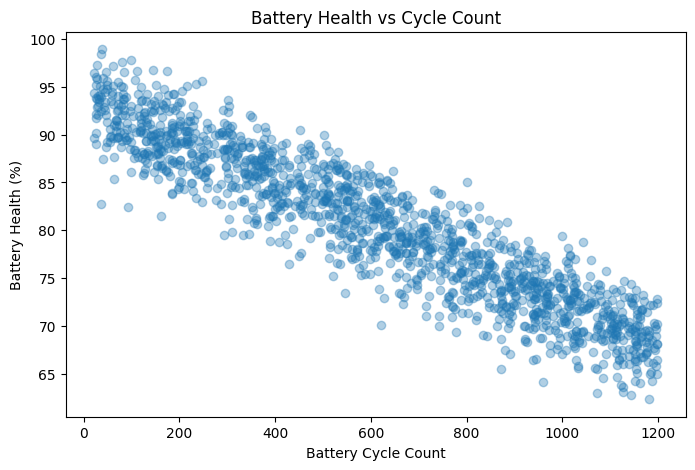

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["cycle_count"],
    df["battery_health_percent"],
    alpha=0.35
)
plt.xlabel("Battery Cycle Count")
plt.ylabel("Battery Health (%)")
plt.title("Battery Health vs Cycle Count")
plt.show()

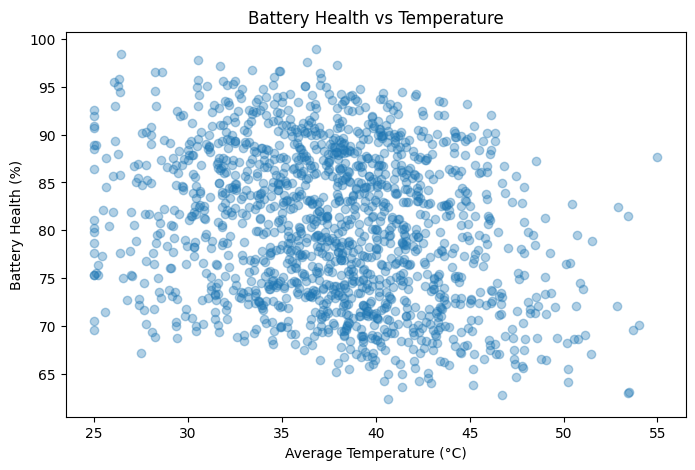

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["temperature_c"],
    df["battery_health_percent"],
    alpha=0.35
)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Battery Health (%)")
plt.title("Battery Health vs Temperature")
plt.show()

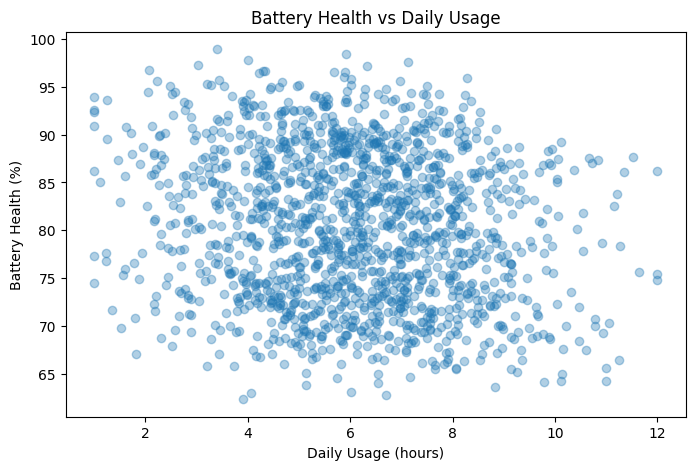

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["daily_usage_hours"],
    df["battery_health_percent"],
    alpha=0.35
)
plt.xlabel("Daily Usage (hours)")
plt.ylabel("Battery Health (%)")
plt.title("Battery Health vs Daily Usage")
plt.show()

In [12]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)
model.fit(X_train, y_train)
print("Model Training Completed!")
y_pred = model.predict(X_test)
print("Predicted Battery Health:")
print(y_pred[:10])
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Model Training Completed!
Predicted Battery Health:
[69.28359756 72.33612177 75.62031448 88.18314139 70.50267452 71.7103224
 75.07236821 76.16756917 69.35680804 77.97210339]
MAE : 1.6457782925287658
RMSE: 2.0403897916783365
R2  : 0.9288922916971565


In [15]:
ample = pd.DataFrame([
    {
        "cycle_count": 400,
        "temperature_c": 40,
        "daily_usage_hours": 6,
        "charging_frequency_per_day": 2,
        "design_capacity_mwh": 50000
    }
])
prediction = model.predict(ample)[0]
prediction = np.clip(prediction, 0, 100)
print("Predicted Battery Health:",
      round(prediction, 2), "%")
if prediction >= 80:
    print("Condition: GOOD")
elif prediction >= 50:
    print("Condition: MODERATE")
else:
    print("Condition: POOR")

Predicted Battery Health: 84.57 %
Condition: GOOD
